In [1]:
#!pip install pandas
#!pip install tensorflow

  Using cached tensorflow-2.11.0-cp39-cp39-win_amd64.whl (1.9 kB)
     ------------------------------------ 266.3/266.3 MB 907.4 kB/s eta 0:00:00
  Using cached opt_einsum-3.3.0-py3-none-any.whl (65 kB)
  Using cached absl_py-1.4.0-py3-none-any.whl (126 kB)
     ---------------------------------------- 3.7/3.7 MB 1.1 MB/s eta 0:00:00
  Using cached termcolor-2.2.0-py3-none-any.whl (6.6 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl (57 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl (12 kB)
  Using cached gast-0.4.0-py3-none-any.whl (9.8 kB)
     ---------------------------------------- 1.5/1.5 MB 1.1 MB/s eta 0:00:00
  Using cached tensorflow_estimator-2.11.0-py2.py3-none-any.whl (439 kB)
     ---------------------------------------- 23.2/23.2 MB 1.0 MB/s eta 0:00:00
     ---------------------------------------- 6.0/6.0 MB 1.1 MB/s eta 0:00:00
     -------------------------------------- 895.9/895.9 kB 1.1 MB/s eta 0:00:00
  Using cached keras-2.11.0-py2.py3-none-any.w

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from statsmodels.tools.eval_measures import rmse, aic
import sklearn
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import tensorflow as tf
from tensorflow import keras
from keras import models, layers, optimizers, regularizers
from keras.models import Model, Sequential
from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.layers import Dense, Dropout, LSTM, RepeatVector, LeakyReLU

tf.random.set_seed(3)
np.random.seed(3)

In [53]:
###  Consumption Dataset ###

preview_e = pd.read_csv("D:\\paper\\C\\data\\5\\realityvalues_cons_90%.csv")
#date = "1/1/2015"

preview_e['date'] = pd.to_datetime(preview_e['date'], format="%m/%d/%Y")

preview_e.set_index('date', inplace=True)

#Manhattan = preview_e.loc[preview_e['Borough'] == 'MANHATTAN']

#electric_manhattan = Manhattan.resample('MS').mean()

#electric_manhattan = pd.DataFrame(electric_manhattan['Consumption (KWH)'])

preview_e

,En_Requests (MJ),co2_emission (kg)
date,,
2013-01-01,156142.30,7703.609
2013-02-01,104397.60,5593.710
2013-03-01,50198.63,3322.159
2013-04-01,21929.05,2157.327
2013-05-01,16551.47,2663.391
...,...,...
2021-08-01,23704.23,3990.169
2021-09-01,15404.05,2477.849
2021-10-01,14286.19,1492.041


In [54]:
### Weather Dataset ### 

preview_w = pd.read_csv('D:\\paper\\C\\data\\5\\realityvalues_weather.csv')

#date = "2015-01-01"

preview_w['date'] = pd.to_datetime(preview_w['date'], format="%Y-%m-%d")

#keep = ['DATE', 'NAME', 'CDSD', 'EMNT', 'EMXT', 'HDSD', 'TAVG', 'TMAX', 'TMIN']

#preview_w = preview_w[keep]

#preview_w = preview_w.rename(columns={'CDSD': 'Cooling Degree Days Season','EMNT': 'Extreme Minimum Temperature','EMXT': 'Extreme Maximum Temperature','HDSD': 'Heating Degree Days Season','TAVG': 'Average Temperature','TMAX': 'Maximum Temperature','TMIN': 'Minimum Temperature'})

preview_w 

,date,Temperature,rel_humidity,solar_hour,Wind_Speed
0,2013-01-01,4.722581,53.850806,215.7,2.838710
1,2013-02-01,8.969643,53.705357,190.8,3.022321
2,2013-03-01,13.286694,48.274194,210.0,3.451613
3,2013-04-01,17.629167,35.912500,280.0,4.545833
4,2013-05-01,23.872177,26.903226,311.4,4.637097
...,...,...,...,...,...
103,2021-08-01,30.116129,16.032258,363.2,3.927419
104,2021-09-01,28.017083,19.737500,305.7,4.737500
105,2021-10-01,16.740726,26.112903,282.8,3.479839
106,2021-11-01,10.424167,42.420833,222.7,2.745833


In [55]:
preview_w.set_index('date', inplace=True)

#central_park = preview_w.loc[preview_w['NAME'] == 'NY CITY CENTRAL PARK, NY US']    

#weather_central_park = central_park.resample('MS').mean()

#weather_central_park = weather_central_park.loc[:'2021-02-01']

In [56]:
### Merge Datasets ###

sab_data = preview_e.merge(preview_w, left_index=True, right_index=True)

### Train-Validation-Test Split ###

dataset = sab_data['2013-01-01':]
data = sab_data['2013-01-01':'2021-12-31'] 
train = data[:'2018-12-31']
val = data['2019-01-01':]
test = sab_data['2022-01-01':]

print('sab_data shape: ', sab_data.shape)
print('data shape: ', data.shape)
print('train shape: ', train.shape)
print('val shape: ', val.shape)
print('test shape: ', test.shape)

### List of Previous Models' Performance ###

performance = ['VAR val (train1) - RMSE: 5,785. MAPE: 15%','VAR test (train1) - RMSE: 8,934. MAPE: 22%','VAR test (train2) - RMSE: 4,809. MAPE: 11%','VARMAX val (train1) - RMSE: 3,630. MAPE: 7%','VARMAX test (train1) - RMSE: 6,227. MAPE: 16%','VARMAX test (train2) - RMSE: 5,639. MAPE: 14%']


sab_data shape:  (108, 6)
data shape:  (108, 6)
train shape:  (72, 6)
val shape:  (36, 6)
test shape:  (0, 6)


In [57]:
dataset

,En_Requests (MJ),co2_emission (kg),Temperature,rel_humidity,solar_hour,Wind_Speed
date,,,,,,
2013-01-01,156142.30,7703.609,4.722581,53.850806,215.7,2.838710
2013-02-01,104397.60,5593.710,8.969643,53.705357,190.8,3.022321
2013-03-01,50198.63,3322.159,13.286694,48.274194,210.0,3.451613
2013-04-01,21929.05,2157.327,17.629167,35.912500,280.0,4.545833
2013-05-01,16551.47,2663.391,23.872177,26.903226,311.4,4.637097
...,...,...,...,...,...,...
2021-08-01,23704.23,3990.169,30.116129,16.032258,363.2,3.927419
2021-09-01,15404.05,2477.849,28.017083,19.737500,305.7,4.737500
2021-10-01,14286.19,1492.041,16.740726,26.112903,282.8,3.479839


In [58]:
# evaluating the forecasts
def adjust(val, length= 6): 
    return str(val).ljust(length)

def forecast_accuracy(forecast, actual):
    mape = np.mean(np.abs(forecast - actual)/np.abs(actual))  # MAPE
    me = np.mean(forecast - actual)             # ME
    mae = np.mean(np.abs(forecast - actual))    # MAE
    mpe = np.mean((forecast - actual)/actual)   # MPE
    rmse = np.mean((forecast - actual)**2)**.5  # RMSE
    corr = np.corrcoef(forecast, actual)[0,1]   # corr
    mins = np.amin(np.hstack([forecast[:,None], 
                              actual[:,None]]), axis=1)
    maxs = np.amax(np.hstack([forecast[:,None], 
                              actual[:,None]]), axis=1)
    minmax = 1 - np.mean(mins/maxs)             # minmax
    print({'mape':mape, 'me':me, 'mae': mae, 
            'mpe': mpe, 'rmse':rmse, 'corr':corr, 'minmax':minmax})

In [59]:
# converting input data into 3-D array as required for LSTM network
def split_sequence(sequence, n_steps):    
    X, y = [], []
    for i in range(len(sequence)):
        # find the end of this pattern
        end_ix = i + n_steps
        # check if we are beyond the sequence
        if end_ix > len(sequence)-1:
            break
        # gather input and output parts of the pattern
        seq_x, seq_y = sequence[i:end_ix], sequence[end_ix]
        X.append(seq_x)
        y.append(seq_y)
    return np.array(X), np.array(y)

In [60]:
### Modeling ###
dataset_values = dataset.values

In [61]:
#dataset.index = pd.to_datetime(data.index)
dataset.index

DatetimeIndex(['2013-01-01', '2013-02-01', '2013-03-01', '2013-04-01',
               '2013-05-01', '2013-06-01', '2013-07-01', '2013-08-01',
               '2013-09-01', '2013-10-01',
               ...
               '2021-03-01', '2021-04-01', '2021-05-01', '2021-06-01',
               '2021-07-01', '2021-08-01', '2021-09-01', '2021-10-01',
               '2021-11-01', '2021-12-01'],
              dtype='datetime64[ns]', name='date', length=108, freq=None)

In [62]:
dataset_values

array([[1.56142300e+05, 7.70360900e+03, 4.72258064e+00, 5.38508065e+01,
        2.15700000e+02, 2.83870968e+00],
       [1.04397600e+05, 5.59371000e+03, 8.96964286e+00, 5.37053571e+01,
        1.90800000e+02, 3.02232143e+00],
       [5.01986300e+04, 3.32215900e+03, 1.32866936e+01, 4.82741935e+01,
        2.10000000e+02, 3.45161290e+00],
       [2.19290500e+04, 2.15732700e+03, 1.76291667e+01, 3.59125000e+01,
        2.80000000e+02, 4.54583333e+00],
       [1.65514700e+04, 2.66339100e+03, 2.38721774e+01, 2.69032258e+01,
        3.11400000e+02, 4.63709677e+00],
       [2.30517800e+04, 3.88021700e+03, 3.00100000e+01, 1.82333333e+01,
        3.29400000e+02, 5.80416667e+00],
       [2.86705000e+04, 4.82618300e+03, 3.22092742e+01, 1.90322581e+01,
        3.77500000e+02, 5.18145161e+00],
       [2.39329000e+04, 4.02868000e+03, 2.90568548e+01, 2.21250000e+01,
        3.42400000e+02, 5.33870968e+00],
       [1.50365600e+04, 2.42812700e+03, 2.78766667e+01, 1.87708333e+01,
        3.16900000e+02, 

In [63]:
scaler = MinMaxScaler(feature_range=(0,1))
#dataset['date'] = dataset['date'].apply(pd.Timestamp.toordinal)

In [64]:
dataset_values

array([[1.56142300e+05, 7.70360900e+03, 4.72258064e+00, 5.38508065e+01,
        2.15700000e+02, 2.83870968e+00],
       [1.04397600e+05, 5.59371000e+03, 8.96964286e+00, 5.37053571e+01,
        1.90800000e+02, 3.02232143e+00],
       [5.01986300e+04, 3.32215900e+03, 1.32866936e+01, 4.82741935e+01,
        2.10000000e+02, 3.45161290e+00],
       [2.19290500e+04, 2.15732700e+03, 1.76291667e+01, 3.59125000e+01,
        2.80000000e+02, 4.54583333e+00],
       [1.65514700e+04, 2.66339100e+03, 2.38721774e+01, 2.69032258e+01,
        3.11400000e+02, 4.63709677e+00],
       [2.30517800e+04, 3.88021700e+03, 3.00100000e+01, 1.82333333e+01,
        3.29400000e+02, 5.80416667e+00],
       [2.86705000e+04, 4.82618300e+03, 3.22092742e+01, 1.90322581e+01,
        3.77500000e+02, 5.18145161e+00],
       [2.39329000e+04, 4.02868000e+03, 2.90568548e+01, 2.21250000e+01,
        3.42400000e+02, 5.33870968e+00],
       [1.50365600e+04, 2.42812700e+03, 2.78766667e+01, 1.87708333e+01,
        3.16900000e+02, 

In [65]:
scaled_data = scaler.fit_transform(dataset_values)

In [66]:
train_data = scaled_data[:72]
val_data = scaled_data[72:108]
test_data = scaled_data[-45:]
len(train_data), len(val_data), len(test_data)

(72, 36, 45)

In [67]:
features = 6
n_steps = 10

In [68]:
X_train, y_train = split_sequence(train_data, n_steps)
X_test, y_test = split_sequence(test_data, n_steps)
X_val, y_val = split_sequence(val_data, n_steps)

In [69]:
X_train.shape, y_train.shape

((62, 10, 6), (62, 6))

In [70]:
from keras.callbacks import EarlyStopping
early = EarlyStopping(monitor='val_loss',patience=5)

# reduce learning rate when a metric has stopped improving
reduce = ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.2, mil_lr=0.001)

In [71]:
test_data.shape

(45, 6)

In [72]:
y_test_re = scaler.inverse_transform(y_test)
y_test_re.shape

(35, 6)

In [73]:
###  Model 1 with RepeatVector  ###

In [74]:


from keras.models import Sequential
from keras.layers import LSTM

model1 = Sequential()
model1.add(LSTM(128, activation='relu', return_sequences=False, input_shape=(n_steps, features)))
model1.add(RepeatVector(n_steps))
model1.add(LSTM(128, activation='relu', return_sequences=False))
model1.add(Dense(features))

model1.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_squared_error'])

In [75]:
history1 = model1.fit(X_train, y_train,
                      epochs=90, batch_size=50, verbose=1,
         validation_data=(X_val, y_val), callbacks=[early,reduce])

Epoch 1/90
2/2 [==============================] - 2s 267ms/step - loss: 0.2875 - mean_squared_error: 0.2875 - val_loss: 0.2477 - val_mean_squared_error: 0.2477 - lr: 0.0010
Epoch 2/90
2/2 [==============================] - 0s 35ms/step - loss: 0.2497 - mean_squared_error: 0.2497 - val_loss: 0.2131 - val_mean_squared_error: 0.2131 - lr: 0.0010
Epoch 3/90
2/2 [==============================] - 0s 39ms/step - loss: 0.2137 - mean_squared_error: 0.2137 - val_loss: 0.1745 - val_mean_squared_error: 0.1745 - lr: 0.0010
Epoch 4/90
2/2 [==============================] - 0s 33ms/step - loss: 0.1725 - mean_squared_error: 0.1725 - val_loss: 0.1301 - val_mean_squared_error: 0.1301 - lr: 0.0010
Epoch 5/90
2/2 [==============================] - 0s 34ms/step - loss: 0.1264 - mean_squared_error: 0.1264 - val_loss: 0.1001 - val_mean_squared_error: 0.1001 - lr: 0.0010
Epoch 6/90
2/2 [==============================] - 0s 34ms/step - loss: 0.1007 - mean_squared_error: 0.1007 - val_loss: 0.1207 - val_mean_sq

In [76]:
model1.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_7 (LSTM)               (None, 128)               69120     
                                                                 
 repeat_vector_1 (RepeatVect  (None, 10, 128)          0         
 or)                                                             
                                                                 
 lstm_8 (LSTM)               (None, 128)               131584    
                                                                 
 dense_3 (Dense)             (None, 6)                 774       
                                                                 
Total params: 201,478
Trainable params: 201,478
Non-trainable params: 0
_________________________________________________________________


In [77]:
# forecasting test set
y_pred1 = model1.predict(X_test)

y_pred1_inv = scaler.inverse_transform(y_pred1)
y_test_inv = scaler.inverse_transform(y_test)

rmse1 = np.sqrt(np.mean(((y_pred1_inv-y_test_inv) ** 2)))
print(f'RMSE：{np.round(rmse1, 4)}')

2/2 [==============================] - 0s 4ms/step
RMSE：19409.0267


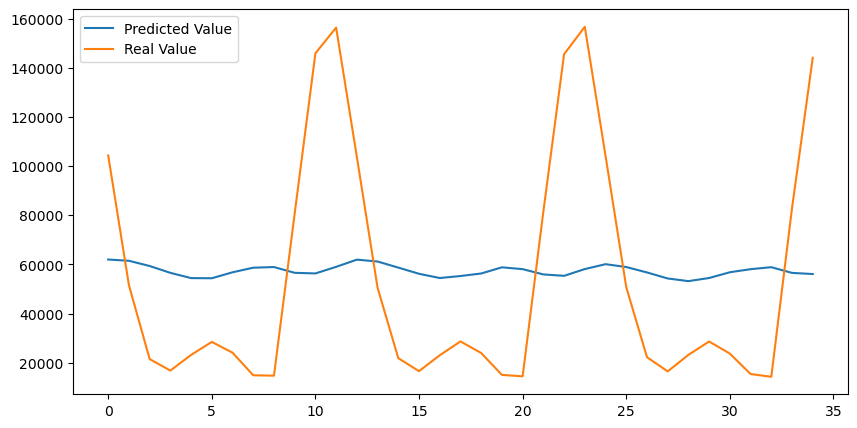

In [78]:
prediction = pd.DataFrame(y_pred1_inv)
testdata= pd.DataFrame(y_test_re)
prediction = prediction.iloc[:, 0].values
testdata = testdata.iloc[:, 0].values

plt.figure(figsize=(10,5))

plt.plot(prediction)
plt.plot(testdata)
plt.legend(['Predicted Value', 'Real Value']);

In [79]:
performance.append('LSTM1 test (train2) - RMSE: 3,154.')
performance

['VAR val (train1) - RMSE: 5,785. MAPE: 15%',
 'VAR test (train1) - RMSE: 8,934. MAPE: 22%',
 'VAR test (train2) - RMSE: 4,809. MAPE: 11%',
 'VARMAX val (train1) - RMSE: 3,630. MAPE: 7%',
 'VARMAX test (train1) - RMSE: 6,227. MAPE: 16%',
 'VARMAX test (train2) - RMSE: 5,639. MAPE: 14%',
 'LSTM1 test (train2) - RMSE: 3,154.']

In [80]:
###   Model 2 with Dropout   ###

In [81]:
model2 = Sequential()
model2.add(LSTM(64, input_shape=(n_steps, features), return_sequences=True))
model2.add(LSTM(32, return_sequences=False))
model2.add(Dropout(0.2))
model2.add(Dense(features))

model2.compile(optimizer='adam', loss='mse', metrics=['accuracy'])

In [82]:
history2=model2.fit(X_train, y_train, epochs=90, validation_data =(X_val, y_val))

Epoch 1/90
2/2 [==============================] - 3s 591ms/step - loss: 0.2556 - accuracy: 0.0806 - val_loss: 0.1928 - val_accuracy: 0.0385
Epoch 2/90
2/2 [==============================] - 0s 31ms/step - loss: 0.1888 - accuracy: 0.1290 - val_loss: 0.1410 - val_accuracy: 0.0385
Epoch 3/90
2/2 [==============================] - 0s 30ms/step - loss: 0.1415 - accuracy: 0.0968 - val_loss: 0.1103 - val_accuracy: 0.0385
Epoch 4/90
2/2 [==============================] - 0s 31ms/step - loss: 0.1145 - accuracy: 0.1613 - val_loss: 0.0979 - val_accuracy: 0.2692
Epoch 5/90
2/2 [==============================] - 0s 28ms/step - loss: 0.1083 - accuracy: 0.1613 - val_loss: 0.0947 - val_accuracy: 0.3846
Epoch 6/90
2/2 [==============================] - 0s 30ms/step - loss: 0.1129 - accuracy: 0.2581 - val_loss: 0.0913 - val_accuracy: 0.2692
Epoch 7/90
2/2 [==============================] - 0s 30ms/step - loss: 0.1025 - accuracy: 0.2903 - val_loss: 0.0859 - val_accuracy: 0.2692
Epoch 8/90
2/2 [==========

2/2 [==============================] - 0s 28ms/step - loss: 0.0239 - accuracy: 0.4355 - val_loss: 0.0203 - val_accuracy: 0.5385
Epoch 60/90
2/2 [==============================] - 0s 28ms/step - loss: 0.0269 - accuracy: 0.4516 - val_loss: 0.0199 - val_accuracy: 0.5385
Epoch 61/90
2/2 [==============================] - 0s 29ms/step - loss: 0.0243 - accuracy: 0.5484 - val_loss: 0.0210 - val_accuracy: 0.6154
Epoch 62/90
2/2 [==============================] - 0s 30ms/step - loss: 0.0261 - accuracy: 0.4677 - val_loss: 0.0207 - val_accuracy: 0.5769
Epoch 63/90
2/2 [==============================] - 0s 34ms/step - loss: 0.0242 - accuracy: 0.5161 - val_loss: 0.0191 - val_accuracy: 0.6538
Epoch 64/90
2/2 [==============================] - 0s 32ms/step - loss: 0.0249 - accuracy: 0.4516 - val_loss: 0.0190 - val_accuracy: 0.6154
Epoch 65/90
2/2 [==============================] - 0s 30ms/step - loss: 0.0233 - accuracy: 0.4355 - val_loss: 0.0194 - val_accuracy: 0.5769
Epoch 66/90
2/2 [===============

In [83]:
model2.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_9 (LSTM)               (None, 10, 64)            18176     
                                                                 
 lstm_10 (LSTM)              (None, 32)                12416     
                                                                 
 dropout_3 (Dropout)         (None, 32)                0         
                                                                 
 dense_4 (Dense)             (None, 6)                 198       
                                                                 
Total params: 30,790
Trainable params: 30,790
Non-trainable params: 0
_________________________________________________________________


In [85]:

y_pred2= model2.predict(X_test)

y_pred2_inv = scaler.inverse_transform(y_pred2)

rmse2 = np.sqrt(np.mean(((y_pred2_inv-y_test_inv) ** 2)))
print(f'RMSE：{np.round(rmse2, 4)}')

2/2 [==============================] - 0s 3ms/step
RMSE：2857.572


<Figure size 1000x500 with 0 Axes>

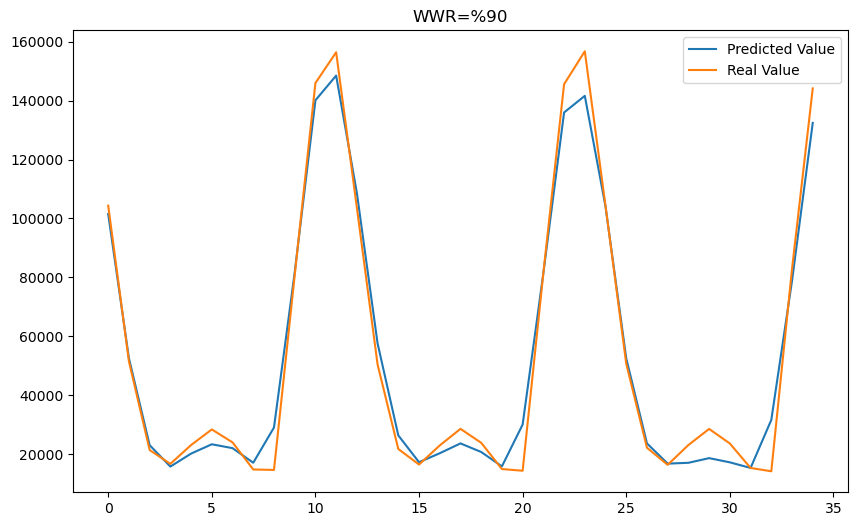

<Figure size 1000x500 with 0 Axes>

In [87]:

prediction2 = pd.DataFrame(y_pred2_inv)
prediction2 = prediction2.iloc[:, 0].values

plt.figure(figsize=(10,6))

plt.plot(prediction2)
plt.plot(testdata)
plt.title("WWR=%90")

plt.legend(['Predicted Value', 'Real Value']);
plt.figure(figsize=(10, 5))



In [43]:
performance.append('LSTM2 test (train2) - RMSE: 1,563.')
performance

['VAR val (train1) - RMSE: 5,785. MAPE: 15%',
 'VAR test (train1) - RMSE: 8,934. MAPE: 22%',
 'VAR test (train2) - RMSE: 4,809. MAPE: 11%',
 'VARMAX val (train1) - RMSE: 3,630. MAPE: 7%',
 'VARMAX test (train1) - RMSE: 6,227. MAPE: 16%',
 'VARMAX test (train2) - RMSE: 5,639. MAPE: 14%',
 'LSTM1 test (train2) - RMSE: 3,154.',
 'LSTM2 test (train2) - RMSE: 1,563.']

In [44]:
###   Model with LeakyReLU   ###

In [45]:

model3 = Sequential()
model3.add(LSTM(128, return_sequences=True, input_shape=(n_steps, features)))
model3.add(LeakyReLU(alpha=0.5))
model3.add(LSTM(128, return_sequences=True))
model3.add(LeakyReLU(alpha=0.5))
model3.add(Dropout(0.3))
model3.add(LSTM(64, return_sequences=False))
model3.add(Dropout(0.3))
model3.add(Dense(features))

model3.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_squared_error', ])

In [46]:
history3 = model3.fit(X_train, y_train, epochs=90, validation_data =(X_val, y_val), callbacks=[early,reduce])


Epoch 1/90
2/2 [==============================] - 4s 769ms/step - loss: 0.2749 - mean_squared_error: 0.2749 - val_loss: 0.2310 - val_mean_squared_error: 0.2310 - lr: 0.0010
Epoch 2/90
2/2 [==============================] - 0s 40ms/step - loss: 0.2227 - mean_squared_error: 0.2227 - val_loss: 0.1815 - val_mean_squared_error: 0.1815 - lr: 0.0010
Epoch 3/90
2/2 [==============================] - 0s 39ms/step - loss: 0.1717 - mean_squared_error: 0.1717 - val_loss: 0.1312 - val_mean_squared_error: 0.1312 - lr: 0.0010
Epoch 4/90
2/2 [==============================] - 0s 40ms/step - loss: 0.1351 - mean_squared_error: 0.1351 - val_loss: 0.1160 - val_mean_squared_error: 0.1160 - lr: 0.0010
Epoch 5/90
2/2 [==============================] - 0s 39ms/step - loss: 0.1276 - mean_squared_error: 0.1276 - val_loss: 0.1021 - val_mean_squared_error: 0.1021 - lr: 0.0010
Epoch 6/90
2/2 [==============================] - 0s 37ms/step - loss: 0.1035 - mean_squared_error: 0.1035 - val_loss: 0.0942 - val_mean_sq

In [47]:
model3.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_4 (LSTM)               (None, 10, 128)           69120     
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 10, 128)           0         
                                                                 
 lstm_5 (LSTM)               (None, 10, 128)           131584    
                                                                 
 leaky_re_lu_1 (LeakyReLU)   (None, 10, 128)           0         
                                                                 
 dropout_1 (Dropout)         (None, 10, 128)           0         
                                                                 
 lstm_6 (LSTM)               (None, 64)                49408     
                                                                 
 dropout_2 (Dropout)         (None, 64)               

In [48]:

y_pred3= model3.predict(X_test)

2/2 [==============================] - 1s 4ms/step


In [49]:
y_pred3_inv = scaler.inverse_transform(y_pred3)

rmse3 = np.sqrt(np.mean(((y_pred3_inv-y_test_inv) ** 2)))
print(f'RMSE：{np.round(rmse3, 4)}')

RMSE：5859.992


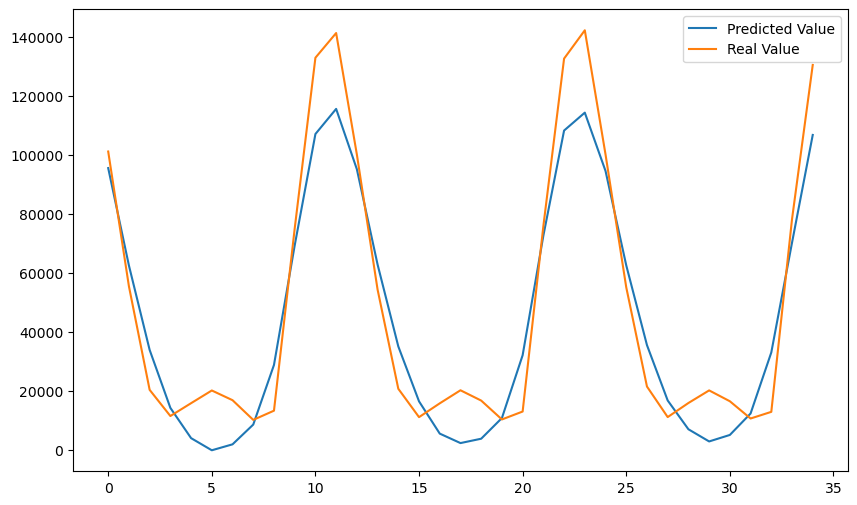

In [50]:
prediction = pd.DataFrame(y_pred3_inv)
prediction = prediction.iloc[:, 0].values

plt.figure(figsize=(10,6))

plt.plot(prediction)
plt.plot(testdata)
plt.legend(['Predicted Value', 'Real Value']);

In [51]:
performance.append('LSTM3 test (train2) - RMSE: 2,572.')
performance

['VAR val (train1) - RMSE: 5,785. MAPE: 15%',
 'VAR test (train1) - RMSE: 8,934. MAPE: 22%',
 'VAR test (train2) - RMSE: 4,809. MAPE: 11%',
 'VARMAX val (train1) - RMSE: 3,630. MAPE: 7%',
 'VARMAX test (train1) - RMSE: 6,227. MAPE: 16%',
 'VARMAX test (train2) - RMSE: 5,639. MAPE: 14%',
 'LSTM1 test (train2) - RMSE: 3,154.',
 'LSTM2 test (train2) - RMSE: 1,563.',
 'LSTM3 test (train2) - RMSE: 2,572.']

In [52]:
# save model
import pickle
with open("forecast_model.pk1", "wb") as f2:
    pickle.dump(model2, f2)
#model2.fit(data, freq="MS")

Keras weights file (<HDF5 file "variables.h5" (mode r+)>) saving:
...layers\dense
......vars
.........0
.........1
...layers\dropout
......vars
...layers\lstm
......vars
...layers\lstm\cell
......vars
.........0
.........1
.........2
...layers\lstm_1
......vars
...layers\lstm_1\cell
......vars
.........0
.........1
.........2
...metrics\mean
......vars
.........0
.........1
...metrics\mean_metric_wrapper
......vars
.........0
.........1
...optimizer
......vars
.........0
.........1
.........10
.........11
.........12
.........13
.........14
.........15
.........16
.........2
.........3
.........4
.........5
.........6
.........7
.........8
.........9
...vars
Keras model archive saving:
File Name                                             Modified             Size
config.json                                    2023-01-27 10:10:42         2779
metadata.json                                  2023-01-27 10:10:42           64
variables.h5                                   2023-01-27 10:10:4

In [63]:
model2

In [64]:
del model2

In [65]:
with open("forecast_model.pk1", "rb") as f2:
      model2 = pickle.load(f2)

Keras model archive loading:
File Name                                             Modified             Size
config.json                                    2023-01-25 23:05:58         2779
metadata.json                                  2023-01-25 23:05:58           64
variables.h5                                   2023-01-25 23:05:58       400480
Keras weights file (<HDF5 file "variables.h5" (mode r)>) loading:
...layers\dense
......vars
.........0
.........1
...layers\dropout
......vars
...layers\lstm
......vars
...layers\lstm\cell
......vars
.........0
.........1
.........2
...layers\lstm_1
......vars
...layers\lstm_1\cell
......vars
.........0
.........1
.........2
...metrics\mean
......vars
.........0
.........1
...metrics\mean_metric_wrapper
......vars
.........0
.........1
...optimizer
......vars
.........0
.........1
.........10
.........11
.........12
.........13
.........14
.........15
.........16
.........2
.........3
.........4
.........5
.........6
.........7
.........8
...

In [66]:
model2

In [67]:
#forcasting
future = model2.iloc[:, 0].values
forecast = model2.predict(future)
forecast

AttributeError: 'Sequential' object has no attribute 'iloc'